In [2]:
import numpy as np 
import os
from pathlib import Path
import subprocess
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from scipy.optimize import curve_fit

PYTHON_SCRIPT_DIR = Path.cwd().resolve()
ROOT = PYTHON_SCRIPT_DIR.parents[1]

In [18]:
for i in range(10):
    data = np.load(f"../../data/test_sweep/run_0/sweep_{i}.npz")
    out = data["outputs"]
    print(out.shape)

(100,)
(100,)
(100,)
(100,)
(100,)


FileNotFoundError: [Errno 2] No such file or directory: '../../data/test_sweep/run_0/sweep_5.npz'

# 1.) Create Batch of I-V curves

In [20]:
from calculate_iv_curve import simulate_iv_curve

PYTHON_SCRIPT_DIR = Path.cwd().resolve()
ROOT = PYTHON_SCRIPT_DIR.parents[1]
DATA_DIR = ROOT / "data" / "iv_normal_sig=0.01_T=200"
DATA_DIR.mkdir(parents=True, exist_ok=True)
CFG_DIR = ROOT / "configs" / "config.txt"
ACC_DIR = ROOT / "configs" / "acceptor_normal.txt"
DON_DIR = ROOT / "configs" / "donors.txt"
ELE_DIR = ROOT / "configs" / "electrodes.txt"
print(str(ROOT))
print(str(DATA_DIR))

batch_size = 20
seed_0 = 420691312

control_indices = [2, 3, 4, 5, 6, 7]

for i in range(batch_size):

    control_voltages = np.random.uniform(-1.5, 1.5, size=(len(control_indices), ))
    control_voltages_dict = {
        idx: voltage for idx, voltage in zip(control_indices, control_voltages)
    }
    seed = seed_0 + np.random.randint(low=0, high=999)
    simulate_iv_curve(name=i, seed=i, save_dir=str(DATA_DIR), cfg_dir=str(CFG_DIR), acc_cfg=str(ACC_DIR), don_cfg=str(DON_DIR), ele_cfg=str(ELE_DIR), params=control_voltages_dict)

/gpfs/bwfor/home/hd/hd_hd/hd_gy283/kmc_project
/gpfs/bwfor/home/hd/hd_hd/hd_gy283/kmc_project/data/iv_normal_sig=0.01_T=200


In [14]:
seed = np.random.randint(low=0, high=999999999)
N = 50
sigmas = np.linspace(0.01, 0.2, N)

a_vals = []

voltage_dict = {
    2: 0.5,
    3: -1.2,
    4: 0.0,
    5: -0.6,
    6: 1.3,
    7: -0.9
}

control_voltage_args = []
for idx, val in voltage_dict.items():
    control_voltage_args.append(f"--c_v={idx}={val}")

input_idx = 1
output_idx = 0
num_of_points = 100
eq_steps = 10_000
sim_steps = 10_000
V_MIN = -1.5
V_MAX = 1.5

ACC_DIR = ROOT / "configs" / "acceptor_normal.txt"
DON_DIR = ROOT / "configs" / "donors.txt"
ELE_DIR = ROOT / "configs" / "electrodes.txt"
DATA_DIR = ROOT / "data" / "sweep_sig"
DATA_DIR.mkdir(parents=True, exist_ok=True)

SWEEP_CONFIGS_DIR = ROOT / "configs" / "sweep_configs"
SWEEP_CONFIGS_DIR.mkdir(parents=True, exist_ok=True)

BINARY = ROOT / "build" / "kmc_project"
SLURM_SCRIPT = ROOT / "scripts" / "slurm" / "helix_optuna.sh"

idx = 0
for s in sigmas:

    cfg_params = {
        "nAcceptors": 200,
        "nDonors": 3,
        "nElectrodes": 8,
        "radius": 150.0,
        "nu0": 1.0,
        "a": 20.0,
        "T": 77.0,
        "energyDisorder": s,
        "electrodeWidth": 60.0,
        "minHopDistance": 1.5,
        "maxHopDistance": 60.0,
        "noDimension": 1
    }

    cfg_dir = ROOT / "configs" / "sweep_configs" / f"config_sig={idx}.txt"
    name = f"point_{idx}"
    flags = [
        f"--file_name={name}",
        f"--sampleSize={30}",
        f"--input_idx={input_idx}",
        f"--output_idx={output_idx}",
        f"--vMin={V_MIN}",
        f"--vMax={V_MAX}",
        f"--numOfPoints={num_of_points}",
        f"--equilibriumSteps={eq_steps}",
        f"--simulationSteps={sim_steps}",
        f"--cfg={cfg_dir}",
        f"--acceptorCfg={str(ACC_DIR)}",
        f"--donorCfg={str(DON_DIR)}",
        f"--electrodeCfg={str(ELE_DIR)}",
        f"--saveFolderPath={str(DATA_DIR)}",
        f"--seed={seed + idx}"
    ]

    
    with open(f"../../configs/sweep_configs/config_sig={idx}.txt", "w") as f:
        for key, val in cfg_params.items():
            f.write(f"{key} {val}\n")

    output_file_name = ROOT / "slurm_out" / "sig_sweep_%j.out"
    slurm_CMD = [
        "sbatch",
        f"--output={output_file_name}",
        str(SLURM_SCRIPT),
        str(BINARY),
        "calcIVCurve"
    ] + flags + control_voltage_args    

    subprocess.run(slurm_CMD, capture_output=True, text=True)

    idx += 1

In [ ]:
def sigmoid_fit(v, I_0, I_1, a, V_2):

    out = I_0 + (I_1 - I_0) / (1 + np.exp(-a*(v - V_2)))

    return out

vs = np.linspace(-1.5, 1.5, 50)

for s in range(0, 20):
    file_name = f"point_{s}.npz"
    data = np.load(f"{ROOT / 'data' / 'sweep_sig' / file_name}")
    print(data["outputs"].shape)
    fit_params, cov = curve_fit(sigmoid_fit, vs, data["outputs"])
    plt.plot(vs, sigmoid_fit(vs, *fit_params))
    plt.scatter(vs, data["outputs"], s=4.5, alpha=.6)

(100,)
(50,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)


num_of_curves: 20
Nonlinearity factor a = 1.9048614900408314


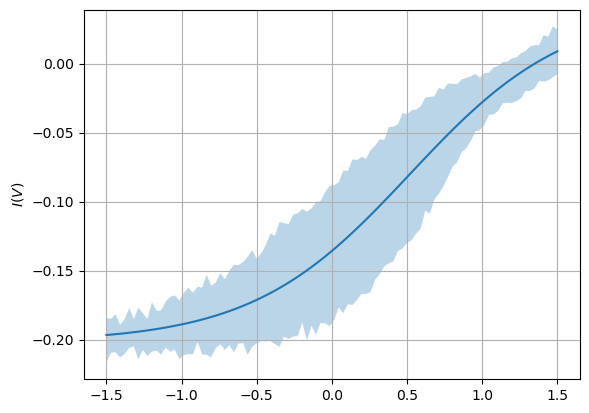

In [26]:
def sigmoid_fit(v, I_0, I_1, a, V_2):

    out = I_0 + (I_1 / (1 + np.exp(-a*(v - V_2))))

    return out

curve_list = []
batch_size = 20
print(f"num_of_curves: {batch_size}")
for i in range(batch_size):
    _curve = np.load(f"../../data/iv_normal_sig=0.01_T=200/data_point_{i}.npz")
    curve_list.append(_curve["outputCurrent"])

np.save(file="../../data/iv_normal_sig=0.01_T=200/curves.npy", arr=np.array(curve_list))

iv_curves = np.load(file="../../data/iv_normal_sig=0.01_T=200/curves.npy")
num_of_points = iv_curves[0].shape[0]

mean = np.mean(iv_curves, axis=0)
std_dev = np.std(iv_curves, ddof=1, axis=0)

vs = np.linspace(-1.5, 1.5, iv_curves.shape[1])

popt, pcov = curve_fit(sigmoid_fit, vs, mean)
print(f"Nonlinearity factor a = {popt[2]}")
plt.plot(vs, sigmoid_fit(vs, *popt))
#plt.plot(vs, mean, lw=2., c='k')
plt.fill_between(vs, mean-std_dev, mean+std_dev, alpha=.3)
plt.ylabel("$I(V)$")
plt.grid(True)

# 2.) Truncated Normal Geometry

In [42]:
radius = 150.0
n_a = 200
n_d = 3
R = np.sqrt(np.pi*radius**2 / n_a)
scaled_radius = radius / R
print(scaled_radius)
print(60. / R)

std_dev = radius / 2.
cov_matrix = (std_dev ** 2) * np.eye(2)

7.978845608028652
3.191538243211461


(200, 2)


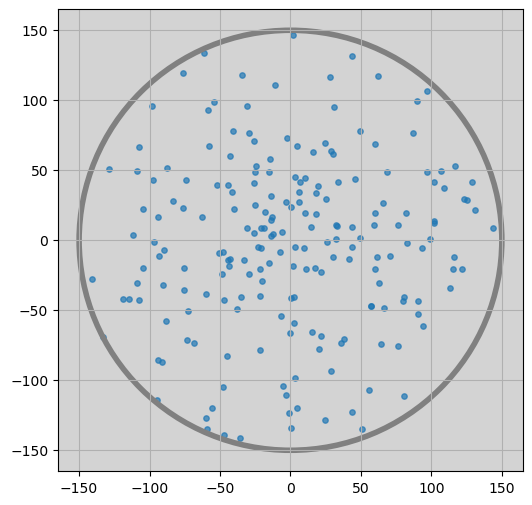

In [43]:
if os.path.isfile("../../configs/acceptor_normal.txt"):
    pass
else:
    file = open("../../configs/acceptor_normal.txt", "x")

acceptor_pos = []

with open("../../configs/acceptor_normal.txt", "w") as f:
    while len(acceptor_pos) < n_a:
        X = np.random.multivariate_normal(mean=np.zeros(2), cov=cov_matrix)
        if np.sqrt(X[0]**2 + X[1]**2) <= radius:
            acceptor_pos.append(X)

with open("../../configs/acceptor_normal.txt", "w") as f:
    for _pos in acceptor_pos:
        f.write(f"{_pos[0]}\t{_pos[1]}\n")

acceptors_array = np.array(acceptor_pos)

fig, ax = plt.subplots(figsize=(6,6))
print(acceptors_array.shape)
ax.scatter(acceptors_array[:,0], acceptors_array[:,1], s=15., alpha=.7)
ax.grid()
ax.set_facecolor("lightgrey")    
boundary = patches.Circle((0, 0), radius=radius, fill=False, edgecolor="gray", lw=4)
ax.add_patch(boundary)


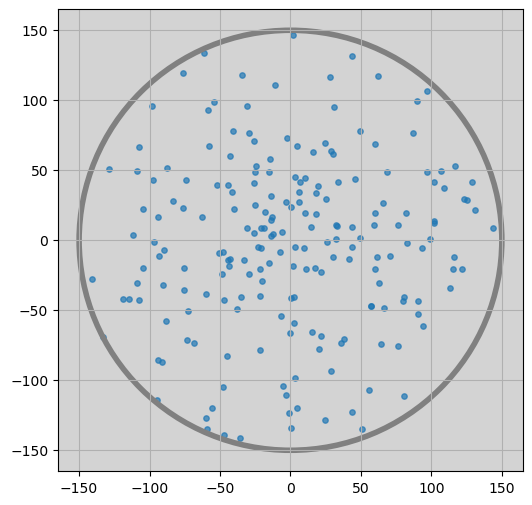

In [44]:
coordinates = []

with open("../../configs/acceptor_normal.txt", "r") as f:
    for _l in f:
        line = _l.strip().split()

        coords = np.array([float(line[0]), float(line[1])])
        coordinates.append(coords)

coordinate_array = np.array(coordinates)

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(coordinate_array[:,0], coordinate_array[:,1], s=15., alpha=.7)
ax.grid()
ax.set_facecolor("lightgrey")    
boundary = patches.Circle((0, 0), radius=radius, fill=False, edgecolor="gray", lw=4)
ax.add_patch(boundary)


['ID', 'inputs', 'outputs']


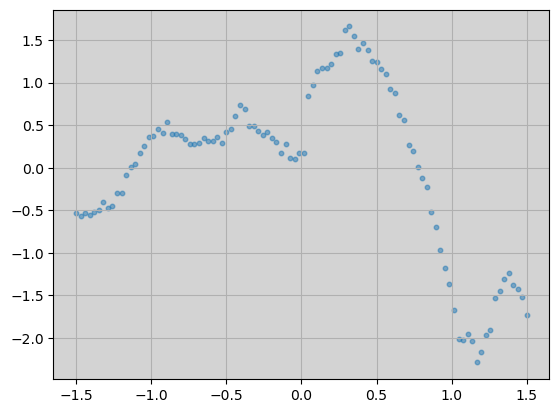

In [91]:
data = np.load("../../data/batch_10002.npz")
inputs = data["inputs"]

print(data.files)
num = len(data["outputs"][0,:])

vs = np.linspace(-1.5, 1.5, num)

plot_kwargs = {
    "s": 10.5,
    "alpha": .5,
}

fig, ax = plt.subplots()

output_mean = np.mean(data["outputs"][0, :])
output_std = np.std(data["outputs"][0, :], ddof=1)
normalized_outputs = (data["outputs"][0, :] - output_mean) / output_std

ax.scatter(vs, normalized_outputs, **plot_kwargs)
ax.grid()
ax.set_facecolor("lightgrey")

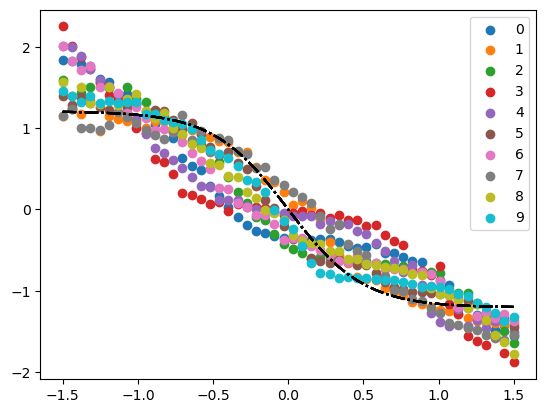

In [132]:
curves = []

num_of_plots = 10
for i in range(num_of_plots):
    data = np.load(f"../../data/trials/data_point_{i}.npz")
    out = data["outputCurrent"]
    out = (out - np.mean(out)) / np.std(out, ddof=1)
    curves.append(out)
vs = np.linspace(-1.5, 1.5, curves[0].shape[0])

def target(x):
    return 1 / (1 + np.exp(4*x))

targets = target(vs)
normalized_targets = (targets - np.mean(targets)) / np.std(targets, ddof=1)

fig, ax = plt.subplots()
for i in range(num_of_plots):
    ax.scatter(vs, curves[i], label=f"{i}")
    ax.plot(vs, normalized_targets, color='k', linestyle="-.")
    plt.legend()

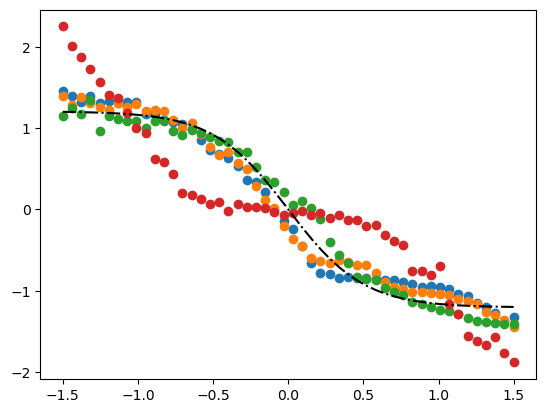

In [137]:
plt.scatter(vs, curves[9])
plt.scatter(vs, curves[5])
plt.scatter(vs, curves[1])
plt.scatter(vs, curves[3])
plt.plot(vs, normalized_targets, color='k', linestyle="-.")